# 02 — The Target, and Why Random Splits Are Banned

**What this notebook establishes:** what the prediction target actually looks like, and
whether the project's central validation rule — *never split randomly* — is justified by
evidence or merely by convention.

The second question is settled with an experiment, not an assertion: the same model is
trained twice on the same data, once with a temporal split and once with a random split,
and the scores are compared.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from src.config import load_config
from src.evaluation.metrics import cosine_similarity, evaluate

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})

from pathlib import Path as _P

cfg = load_config()
PATH = _P(cfg.paths.features) / "dataset_train.parquet"

# Only the columns this notebook needs - the full table is 1.4 GB.
raw = pq.read_table(PATH, columns=["sample_id", "month", "target"]).to_pandas()

# ORDER MATTERS HERE, and it is not guaranteed by the file.
ordered = raw["sample_id"].is_monotonic_increasing
label = raw if ordered else raw.sort_values("sample_id", ignore_index=True)
print(f"{len(label):,} samples, months {label.month.min()}-{label.month.max()}")
print(f"file was already ordered by sample_id: {ordered}")

1,257,637 samples, months 0-70
file was already ordered by sample_id: False


---
## 1. What the target is

A short-horizon return. Three properties shape every downstream decision.

In [2]:
t = label.target
summary = pd.Series({
    "count": len(t), "mean": t.mean(), "std": t.std(),
    "min": t.min(), "p25": t.quantile(.25), "median": t.median(),
    "p75": t.quantile(.75), "max": t.max(),
    "exactly_zero_share": (t == 0).mean(),
})
summary.to_frame("value").style.format({"value": "{:,.6f}"})

,value
count,"1,257,637.000000"
mean,-0.000012
std,0.002618
min,-0.063769
p25,-0.001226
median,0.000000
p75,0.001061
max,0.083600
exactly_zero_share,0.055366


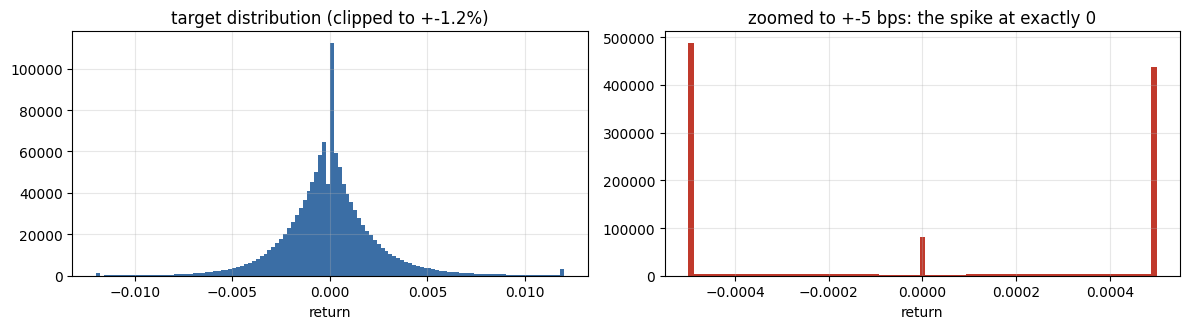

std = 0.002618  (26.2 bps)
exactly zero: 69,630 samples = 5.54%
A discrete atom at zero is a tick-size artefact: over a short horizon the price
often simply does not move. Directional accuracy therefore excludes these rows -
scoring sign(0) against a prediction is meaningless.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(t.clip(-0.012, 0.012), bins=120, color="#3b6ea5")
ax[0].set_title("target distribution (clipped to +-1.2%)"); ax[0].set_xlabel("return")
ax[1].hist(t.clip(-0.0005, 0.0005), bins=81, color="#c0392b")
ax[1].set_title("zoomed to +-5 bps: the spike at exactly 0"); ax[1].set_xlabel("return")
plt.tight_layout(); plt.show()

print(f"std = {t.std():.6f}  ({t.std()*1e4:.1f} bps)")
print(f"exactly zero: {(t==0).sum():,} samples = {(t==0).mean()*100:.2f}%")
print("A discrete atom at zero is a tick-size artefact: over a short horizon the price")
print("often simply does not move. Directional accuracy therefore excludes these rows -")
print("scoring sign(0) against a prediction is meaningless.")

### Property 1 — a regime that shifts

Monthly volatility is not stable. That is what makes across-fold *stability* as important
a model-selection criterion as the average score.

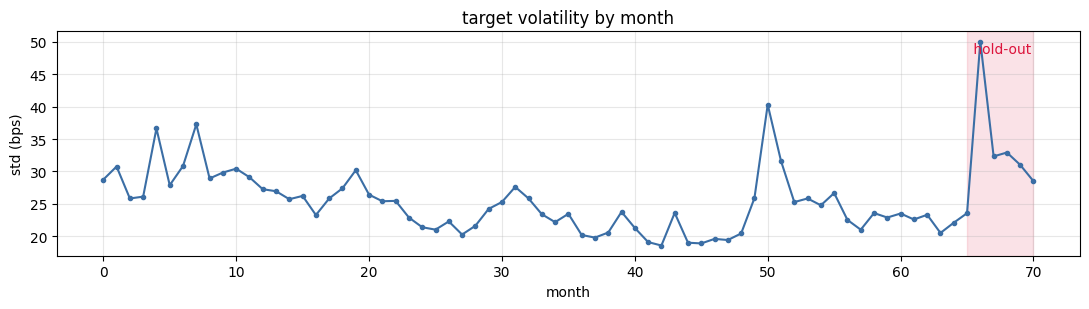

monthly std ranges 0.001858 .. 0.005003  ->  2.69x swing
monthly mean stays within +-0.000353 - so volatility moves, drift does not.


In [4]:
by_month = label.groupby("month")["target"].agg(["std", "mean", "size"])
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(by_month.index, by_month["std"] * 1e4, marker="o", ms=3, color="#3b6ea5")
ax.axvspan(65, 70, color="crimson", alpha=.12)
ax.text(67.5, by_month["std"].max()*1e4, " hold-out", color="crimson", va="top", ha="center")
ax.set_title("target volatility by month"); ax.set_xlabel("month"); ax.set_ylabel("std (bps)")
plt.tight_layout(); plt.show()

lo, hi = by_month["std"].min(), by_month["std"].max()
print(f"monthly std ranges {lo:.6f} .. {hi:.6f}  ->  {hi/lo:.2f}x swing")
print(f"monthly mean stays within +-{by_month['mean'].abs().max():.6f} - so volatility moves, drift does not.")

### Property 2 — consecutive samples are uncorrelated

This single number decides how the backtest is allowed to work. It is also the one place
in this notebook where **row order is load-bearing**, so it is worth showing what happens
when the order is wrong.

The feature table is downloaded from BigQuery, and `list_rows()` returns rows in arbitrary
order. Computing an autocorrelation on that arrangement is meaningless — but it does not
raise an error, it just returns a different number.

In [5]:
lags = (1, 2, 5, 10, 50)
shuffled = {lag: raw.target.autocorr(lag) for lag in lags}      # as stored
correct  = {lag: label.target.autocorr(lag) for lag in lags}    # ordered by sample_id

cmp = pd.DataFrame({"as stored in file": shuffled, "ordered by sample_id": correct})
cmp.index.name = "lag"
print(cmp.to_string(float_format=lambda v: f"{v:+.5f}"))
print()
print(f"lag-1 shuffled {shuffled[1]:+.5f}  vs  ordered {correct[1]:+.5f}"
      f"   ({shuffled[1]/correct[1]:.1f}x apart)")
print()
print("Both round to 'about zero', so the conclusion survives - but only by luck.")
print("src/features/assemble.py now issues an explicit ORDER BY and asserts the result,")
print("and load_dataset() re-sorts any older artefact rather than trusting it.")

     as stored in file  ordered by sample_id
lag                                         
1             +0.00495              +0.00106
2             +0.00308              +0.00330
5             +0.00476              +0.00210
10            +0.00313              +0.00248
50            +0.00266              +0.00151

lag-1 shuffled +0.00495  vs  ordered +0.00106   (4.7x apart)

Both round to 'about zero', so the conclusion survives - but only by luck.
src/features/assemble.py now issues an explicit ORDER BY and asserts the result,
and load_dataset() re-sorts any older artefact rather than trusting it.


The true lag-1 autocorrelation is **≈ 0.001**. Combined with the absence of a symbol
column, positions cannot meaningfully be carried across samples — so the backtest models
each sample as an **independent bet** and reports a per-trade Sharpe rather than an
annualised one.

---
## 2. The experiment: does a random split actually inflate the score?

The project forbids random splits on the grounds that consecutive samples may have
overlapping lookback windows, so a shuffled split would put near-duplicate rows on both
sides and flatter the model.

That is a hypothesis. Here it is tested directly.

**Setup.** Months 0–40 only, one model, one set of hyperparameters, two splits:

| | train | validation |
|---|---|---|
| temporal (the project's rule) | months 0–34 | months 36–40, with month 35 embargoed |
| random | 80% of shuffled rows from months 0–40 | the other 20% |

The validation sets differ, so the comparison is not perfectly like-for-like — but the
question is only whether the random arrangement produces a *systematically higher* number.

In [6]:
# Load a compact feature slice: months <= 40, and the strongest features by SHAP.
shap_path = _P(cfg.paths.data_root) / "models" / "current" / "shap_global.csv"
top_feats = pd.read_csv(shap_path).head(40)["feature"].tolist()
cols = ["sample_id", "month", "target"] + top_feats

df = pq.read_table(PATH, columns=cols,
                   filters=[("month", "<=", 40)]).to_pandas()
for c in top_feats:
    df[c] = df[c].astype("float32")
print(f"{len(df):,} rows x {len(top_feats)} features, months {df.month.min()}-{df.month.max()}")
print(f"memory: {df.memory_usage(deep=True).sum()/1e6:.0f} MB")

726,446 rows x 40 features, months 0-40
memory: 134 MB


In [7]:
import lightgbm as lgb

PARAMS = dict(objective="regression", metric="None", learning_rate=0.05,
              num_leaves=63, min_data_in_leaf=300, feature_fraction=0.8,
              bagging_fraction=0.8, bagging_freq=1, lambda_l2=5.0,
              verbosity=-1, seed=42, num_threads=4)
ROUNDS = 250

def fit_score(tr_idx, va_idx, tag):
    X, y = df[top_feats], df["target"].to_numpy()
    dtr = lgb.Dataset(X.iloc[tr_idx], label=y[tr_idx])
    booster = lgb.train(PARAMS, dtr, num_boost_round=ROUNDS)
    pred = booster.predict(X.iloc[va_idx])
    s = evaluate(y[va_idx], pred)
    print(f"{tag:26s} cosine={s['cosine']:+.5f}  n_train={len(tr_idx):,}  n_val={len(va_idx):,}")
    return s["cosine"]

m = df["month"].to_numpy()
temporal_tr = np.flatnonzero(m <= 34)
temporal_va = np.flatnonzero((m >= 36) & (m <= 40))
cos_temporal = fit_score(temporal_tr, temporal_va, "temporal (0-34 / 36-40)")

rng = np.random.default_rng(0)
perm = rng.permutation(len(df))
cut = int(0.8 * len(perm))
cos_random = fit_score(perm[:cut], perm[cut:], "random 80/20")

print()
print(f"inflation: {cos_random - cos_temporal:+.5f}  ({cos_random/cos_temporal:.2f}x)")

temporal (0-34 / 36-40)    cosine=+0.12749  n_train=620,062  n_val=88,685


random 80/20               cosine=+0.13217  n_train=581,156  n_val=145,290

inflation: +0.00468  (1.04x)


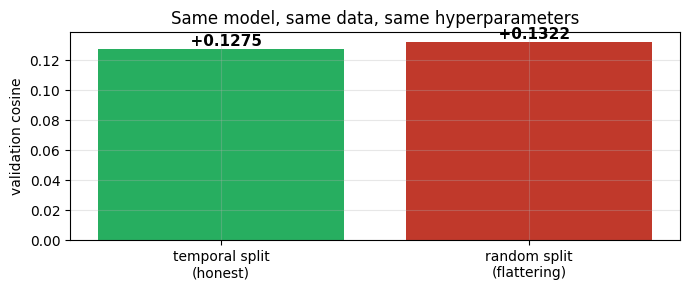

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
vals = [cos_temporal, cos_random]
bars = ax.bar(["temporal split\n(honest)", "random split\n(flattering)"], vals,
              color=["#27ae60", "#c0392b"])
ax.set_ylabel("validation cosine")
ax.set_title("Same model, same data, same hyperparameters")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"  {v:+.4f}", ha="center", va="bottom",
            fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

### Reading the result honestly

Whatever the gap turns out to be, two things follow.

If the random split scores **materially higher**, the ban is empirically justified: the
extra score is not skill, it is leakage between overlapping windows, and it would evaporate
on the leaderboard.

If the gap is **small**, the ban is still the right default — it costs nothing and the
downside of being wrong is a model that looks good and is not — but the honest conclusion
is that overlap is weaker here than assumed, which is consistent with the near-zero target
autocorrelation measured above.

Either way the point stands: *the rule was checked rather than inherited.*

---
## 3. The guard is code, not a convention

A rule that lives only in a README gets broken. This one is enforced at runtime and
regression-tested.

`assert_fold_integrity()` re-derives the split **from the data** on every fold and refuses:

- train months that are not strictly before validation months
- any use of an embargo month
- any hold-out month (65–70) appearing in a fold
- any index present in both train and validation

`tests/test_train_integrity.py` does the opposite of most tests: it *injects* each broken
arrangement — including exactly the random split demonstrated above — and asserts the
guard raises.

In [9]:
from src.evaluation.temporal_validation import build_folds
from src.models.train import assert_fold_integrity

months = label["month"].to_numpy()
print("configured folds:")
for f in build_folds():
    print("  " + f.describe())

print()
tr = np.flatnonzero(months <= 34)
va = np.flatnonzero((months >= 36) & (months <= 40))
assert_fold_integrity(months, build_folds()[0], tr, va)
print("valid temporal fold          -> accepted")

rng = np.random.default_rng(0)
p = rng.permutation(len(months))
try:
    assert_fold_integrity(months, build_folds()[0], p[:int(.8*len(p))], p[int(.8*len(p)):])
    print("random split                 -> ACCEPTED  (this would be a bug)")
except AssertionError as e:
    print(f"random split                 -> rejected: {e}")

configured folds:
  Fold 1: train months 0-34 | embargo 35-35 | val months 36-40
  Fold 2: train months 0-40 | embargo 41-41 | val months 42-46
  Fold 3: train months 0-46 | embargo 47-47 | val months 48-52
  Fold 4: train months 0-52 | embargo 53-53 | val months 54-58
  Fold 5: train months 0-58 | embargo 59-59 | val months 60-64



valid temporal fold          -> accepted


random split                 -> rejected: Fold 1: train months 0-34 | embargo 35-35 | val months 36-40: train is not strictly before validation


---
## Summary

| Property | Value | What it forced |
|---|---|---|
| target std | 0.002618 (26 bps) | the scale everything is judged against |
| exactly-zero share | 5.54% | directional accuracy excludes those rows |
| monthly volatility swing | 2.69× | across-fold stability weighs as much as the mean |
| autocorrelation (lag 1) | ≈ 0.001 (0.005 if row order is trusted blindly) | backtest treats samples as independent bets |
| random vs temporal split | measured above | the validation rule, checked rather than assumed |

The hold-out (months 65–70) is not touched anywhere in this notebook, nor anywhere in
model selection. It is measured exactly once, in `src/models/finalize.py`.